In [ ]:
import torch
from monai.utils import optional_import
from monai.data.box_utils import StandardMode, get_spatial_dims
from monai.apps.detection.transforms.array import ConvertBoxToStandardMode
import torch_geometric.data as data

# convert boxes to points coord
def boxes_to_coord(boxes, spatial_size, mode=StandardMode):
    center = []
    for i in (spatial_size):
        center.append(i // 2)
    box_converter = ConvertBoxToStandardMode(mode=mode)
    boxes_t = box_converter(boxes)
    spatial_dims = get_spatial_dims(boxes=boxes_t)
    if spatial_dims == 2:
        x1, y1, x2, y2 = boxes.split(1, dim=-1)
        coords = torch.tensor([[x1, y1], [x1, y2], [x2, y1], [x2, y2]])
    elif spatial_dims == 3:
        x1, y1, z1, x2, y2, z2 = boxes.split(1, dim=-1)
        coords = torch.tensor(
            [
                [x1, y1, z1], [x1, y2, z1], [x2, y1, z1], [x2, y2, z1],
                [x1, y1, z2], [x1, y2, z2], [x2, y1, z2], [x2, y2, z2]
            ])
    coords -= torch.tensor(center)
    return coords

In [ ]:
class Geometric:
    """
    This is a wrapper transform for PyTorch Geometric transform based on the specified transform name and args.
    """

    def __init__(self, name: str, *args, **kwargs) -> None:
        """
        Args:
            name: The transform name in Geometric package.
            args: parameters for the Geometric transform.
            kwargs: parameters for the Geometric transform.

        """
        super().__init__()
        self.name = name
        transform, _ = optional_import("torch_geometric.transforms", name=name)
        self.trans = transform(*args, **kwargs)

    def __call__(self, pos, spatial_size):
        center = []
        for i in (spatial_size):
            center.append(i // 2)
        data_geometric = data.Data(pos=pos)

        out = self.trans(data_geometric)
        out_geometric = out.pos
        out_geometric += torch.tensor(center)
        return out_geometric

In [ ]:
boxes = torch.tensor([[1, 3, 3, 7]]) # StandardMode: xyxy

pos = boxes_to_coord(boxes=boxes, spatial_size=[10, 10])
Geometric("RandomFlip", axis=1, p=1)(pos=pos, spatial_size=[10, 10])

In [ ]:
import torch_geometric.transforms as T
T.RandomScale(scales=[0.5, 0.5])

In [ ]:
Geometric("RandomRotate", degrees=[90, 90], axis=1)(pos=pos, spatial_size=[10, 10])

In [ ]:
Geometric("RandomScale", scales=[0.5, 0.5])(pos=pos, spatial_size=[10, 10])

In [ ]:
from monai.apps.detection.transforms.array import FlipBox, RotateBox90, ZoomBox

boxes = torch.tensor([[1, 3, 3, 7]]) # StandardMode: xyxy
trans_monai = FlipBox(spatial_axis=0)
trans_monai(boxes=boxes, spatial_size=(10, 10))

In [ ]:
from monai.transforms import Flip, Flipd
from monai.data import MetaTensor
import torch

boxes = MetaTensor(torch.tensor([[1, 3], [3, 7]]), meta={"kind": "point"})

trans = Flip(spatial_axis=0, spatial_size=(10, 10))
transd = Flipd(keys="point", spatial_axis=0, spatial_size=(10, 10))


print(transd({"point": boxes}), trans(boxes))

In [ ]:
trans_monai = RotateBox90(spatial_axes=(1, 0))
trans_monai(boxes=boxes, spatial_size=(10, 10))

In [ ]:
trans_monai = ZoomBox(zoom=0.5)
trans_monai(boxes=boxes)

In [7]:
import json
import matplotlib.pyplot as plt
from monai.data import MetaTensor
from monai.transforms import LoadImage, Flipd, Resized, Compose

def vis_keypoints(image, keypoints, color="red", diameter=20):
    plt.figure(figsize=(8, 8))
    fig, ax = plt.subplots()
    ax.scatter([p[1] for p in keypoints], [p[0] for p in keypoints], color=color, s=diameter)
    plt.imshow(image.squeeze(), cmap="gray")

image_path = "/workspace/Data/Geometric-demo/image.jpg"
label_path = "/workspace/Data/Geometric-demo/label.json"

image = LoadImage(ensure_channel_first=True)(image_path)
with open(label_path) as f:
    label = json.load(f)
points = label["shapes"][-1]["points"]

data = {"image": MetaTensor(image, meta={"kind": "pixel"}), "point": MetaTensor(points, meta={'kind': "point"})}

<Figure size 800x800 with 0 Axes>

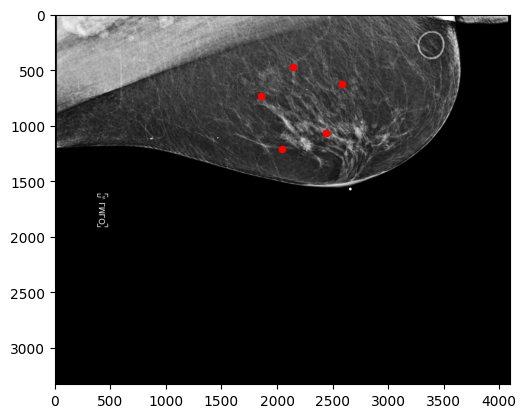

In [8]:
vis_keypoints(image, points)

In [9]:
trans_compose = Compose([
    Flipd(keys=["image", "point"], spatial_axis=0, spatial_size=(3328, 4096)),
    Resized(keys=["image", "point"], spatial_size=[1664, 2048], src_spatial_size=(3328, 4096))
])
out_trans_compose = trans_compose(data)

<Figure size 800x800 with 0 Axes>

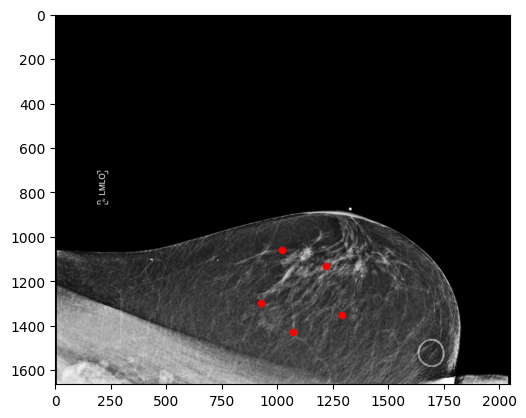

In [10]:
vis_keypoints(out_trans_compose["image"], out_trans_compose["point"])